# 23 Feb 2026
- combining CVs in emgap (drawn from 2d mchirp, fgw dist and assigned positions with same prescription as Scaringi+23) with original Scaringi+23 population

In [1]:
import numpy as np
from scipy import stats, interpolate
from matplotlib import pyplot as plt
import astropy.units as u
import astropy.constants as apyconst
import pandas as pd
import legwork as lw
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
import copy
import corner
import astropy.coordinates as cc
import healpy as hp


%matplotlib inline
%config InlineBackend.figure_format='retina'

# LSS lets import position function from Scaringi et al 2023
import sys
sys.path.append('/home/levis/lisa_projects/blip_CVs/cataclysmic-pileup-paper/src/scripts/')
from CV_pop_create_chirpm import sample_position_from_Pala_2020


In [2]:
file = '/home/levis/lisa_projects/blip_CVs/datasets/scaringi_data/dat_maxDistance_1000_final.txt'
CV_pop = pd.read_csv(file)

In [4]:
# LSS this is freq [Hz], chirp mass [Msun], x,y,z [kpc] in galactic coordinates
CV_gap = np.load('fmc_gap_seed42_with_positions_seed41_20260223.npy')

In [5]:
CV_gap.shape

(537, 5)

## lets look at sky positions

In [6]:
## convert to distances and lat/long ecliptic coords
gc_gap = cc.SkyCoord(CV_gap[:, 2]*u.kpc,CV_gap[:, 3]*u.kpc,CV_gap[:, 4]*u.kpc, frame='galactic', representation_type='cartesian')
SSBc_gap = gc_gap.transform_to(cc.BarycentricMeanEcliptic)
## get latitude, longitude
lat_gap = SSBc_gap.lat.to(u.rad).value
long_gap = SSBc_gap.lon.to(u.rad).value

xG, yG, zG = CV_pop[' x_gal[kpc]'].to_numpy(), CV_pop[' y_gal[kpc]'].to_numpy(), CV_pop[' z_gal[kpc]'].to_numpy()
## convert to distances and lat/long ecliptic coords
gc_CVpop = cc.SkyCoord(x=xG*u.kpc,y=yG*u.kpc,z=zG*u.kpc, frame='galactocentric')
SSBc_CVpop = gc_CVpop.transform_to(cc.BarycentricMeanEcliptic)
## get latitude, longitude
lat_CVpop = SSBc_CVpop.lat.to(u.rad).value
long_CVpop = SSBc_CVpop.lon.to(u.rad).value

<Figure size 1200x800 with 0 Axes>

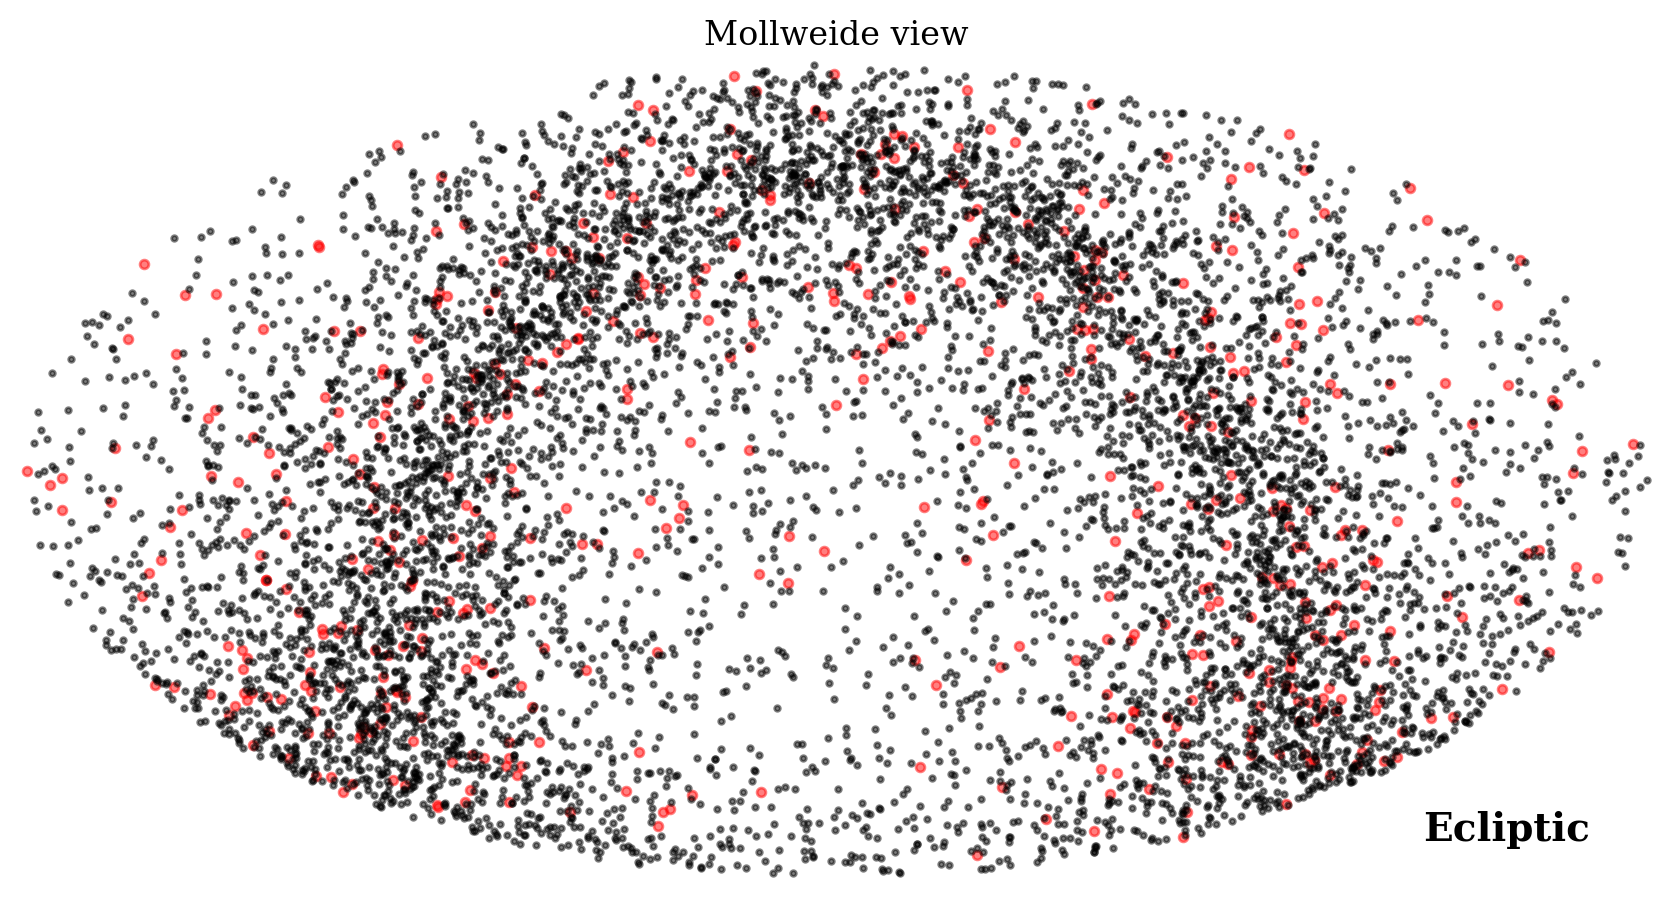

In [7]:
## check
plt.figure()
hp.mollview(coord='E')
hp.projscatter(long_gap*u.rad.to(u.deg),lat_gap*u.rad.to(u.deg),lonlat=True,color='r',alpha=0.5,s=10)
hp.projscatter(long_CVpop*u.rad.to(u.deg),lat_CVpop*u.rad.to(u.deg),lonlat=True,color='k',alpha=0.5,s=4)
plt.show()

## what about freq distribution

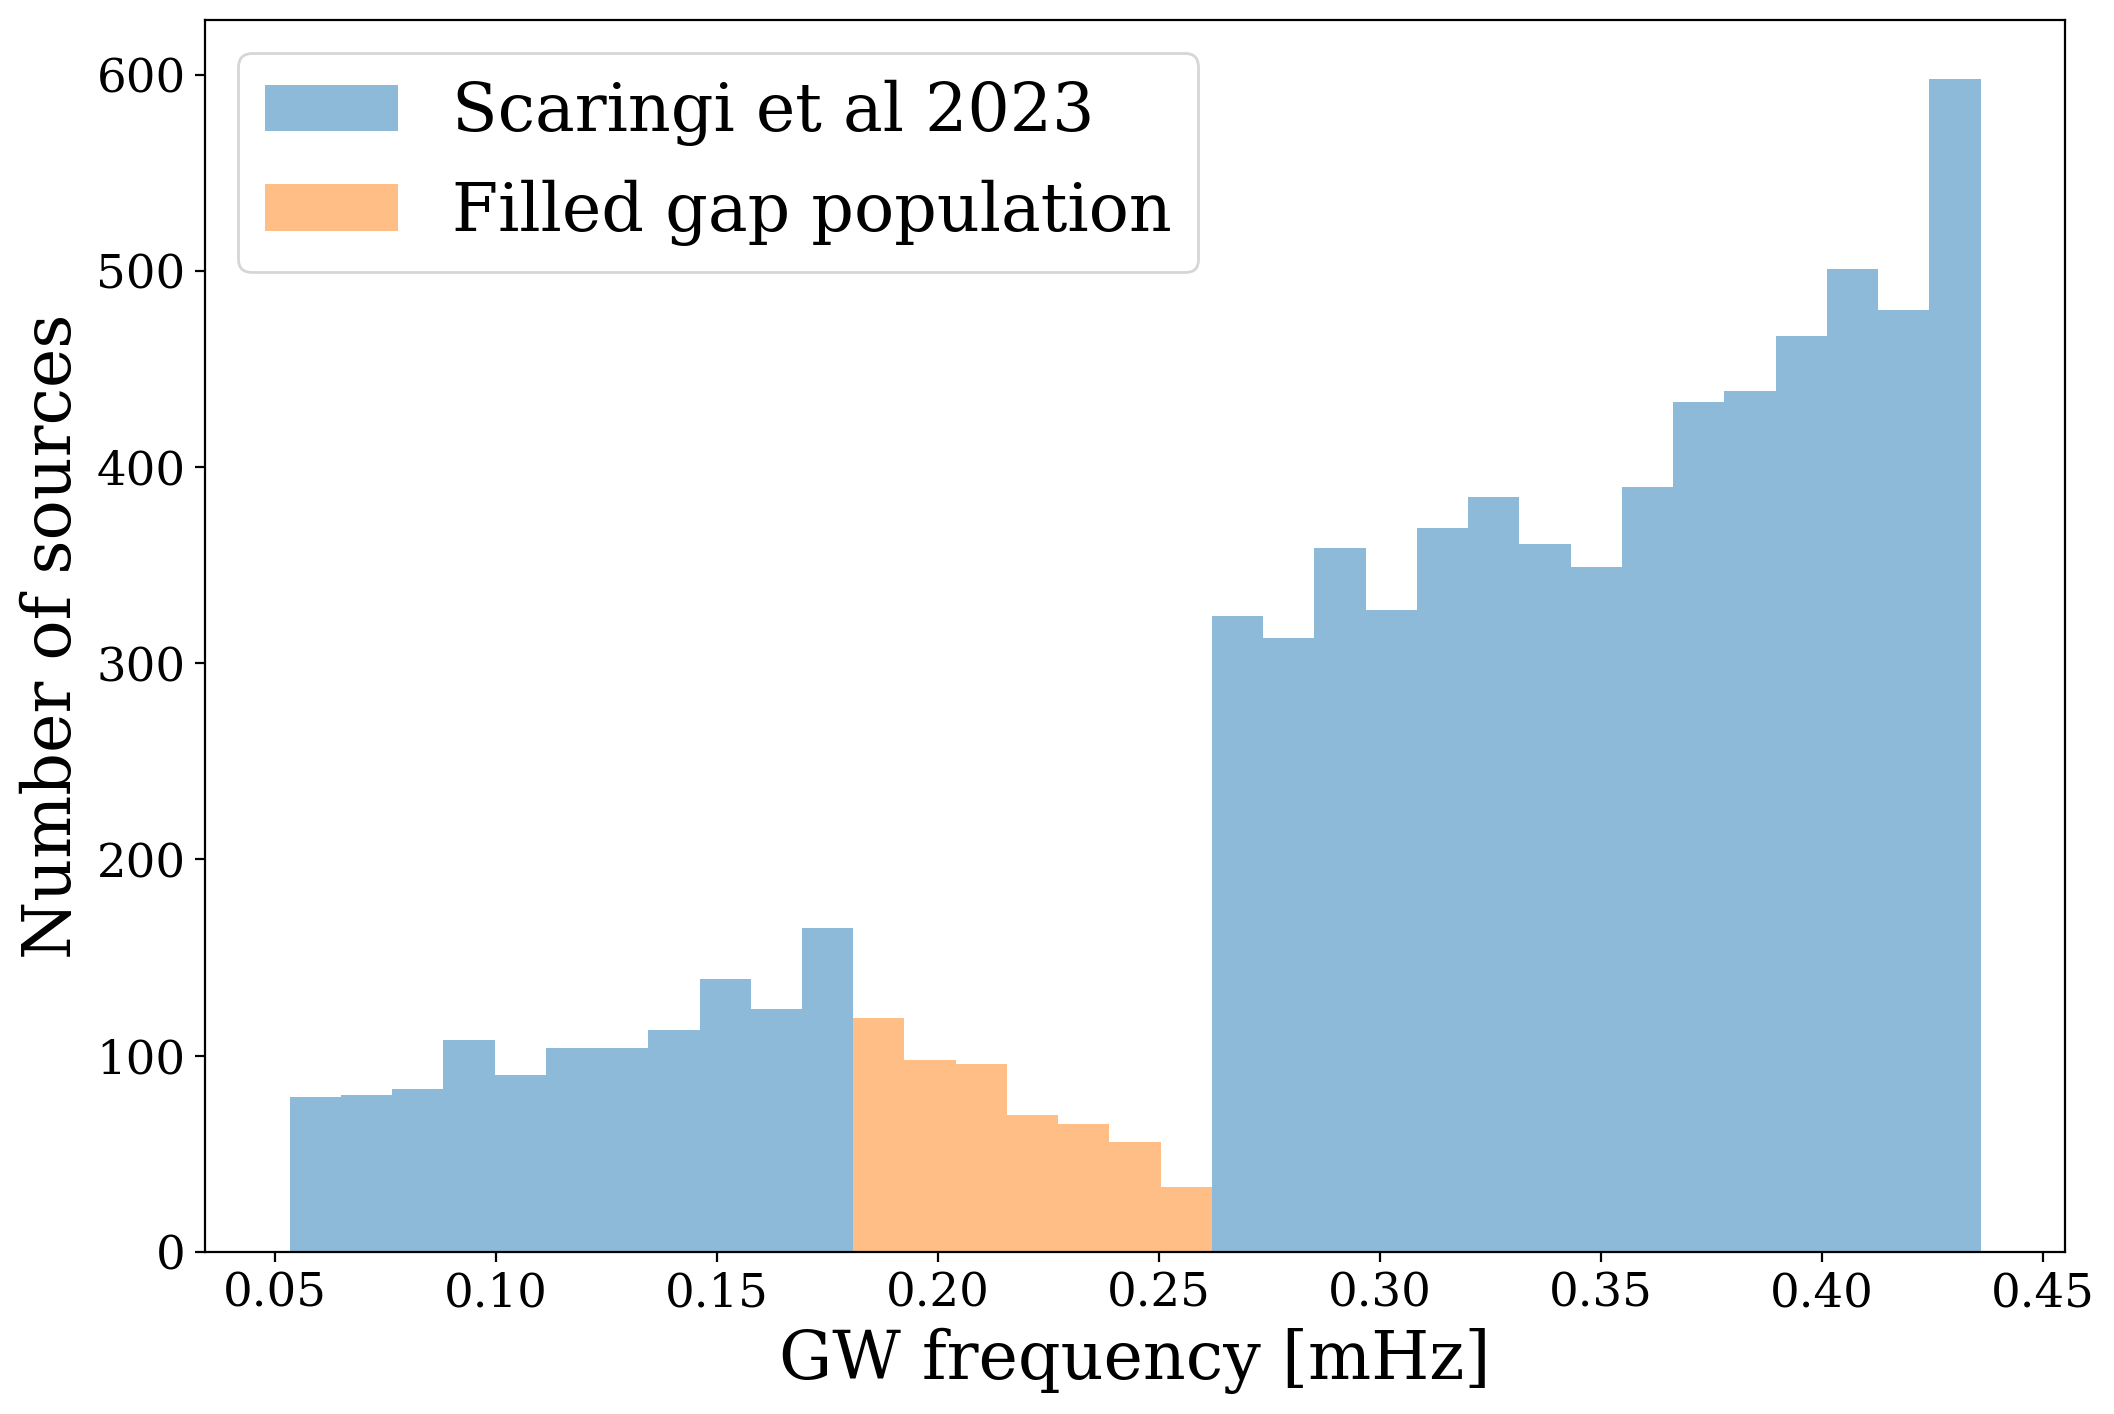

In [12]:
freqbins = np.linspace(np.min(CV_pop[' f_gw[Hz]']), np.max(CV_pop[' f_gw[Hz]']), 34)*1e3
plt.hist(CV_pop[' f_gw[Hz]']*1e3, bins=freqbins, alpha=0.5, label='Scaringi et al 2023')
plt.hist(CV_gap[:, 0]*1e3, bins=freqbins, alpha=0.5, label='Filled gap population')
plt.legend()
plt.xlabel('GW frequency [mHz]')
plt.ylabel('Number of sources')
plt.show()

## lets make a file BLIP can read!

In [13]:
# LSS blip needs f, h, lat, lon

# LSS lets again get the strains for the original CV pop from Scaringi+23
dist_CVpop = SSBc_CVpop.distance.to(u.kpc)
mc_CVpop = lw.utils.chirp_mass(CV_pop['# m1[Msun]'],CV_pop[' m2[Msun]']).to_numpy()*u.Msun
fs_CVpop = CV_pop[' f_gw[Hz]'].to_numpy()
f_orb_CVpop = fs_CVpop*u.Hz/2
## assuming circular binaries
ecc = np.zeros(len(f_orb_CVpop))
hs_CVpop = lw.strain.h_0_n(mc_CVpop,f_orb_CVpop,ecc,2,dist_CVpop)

# LSS now get the strains for the gap population
dist_gap = SSBc_gap.distance.to(u.kpc)
mc_gap = CV_gap[:, 1]*u.Msun
f_orb_gap = CV_gap[:, 0]*u.Hz/2
ecc_gap = np.zeros(len(f_orb_gap))
hs_gap = lw.strain.h_0_n(mc_gap,f_orb_gap,ecc_gap,2,dist_gap)


[]

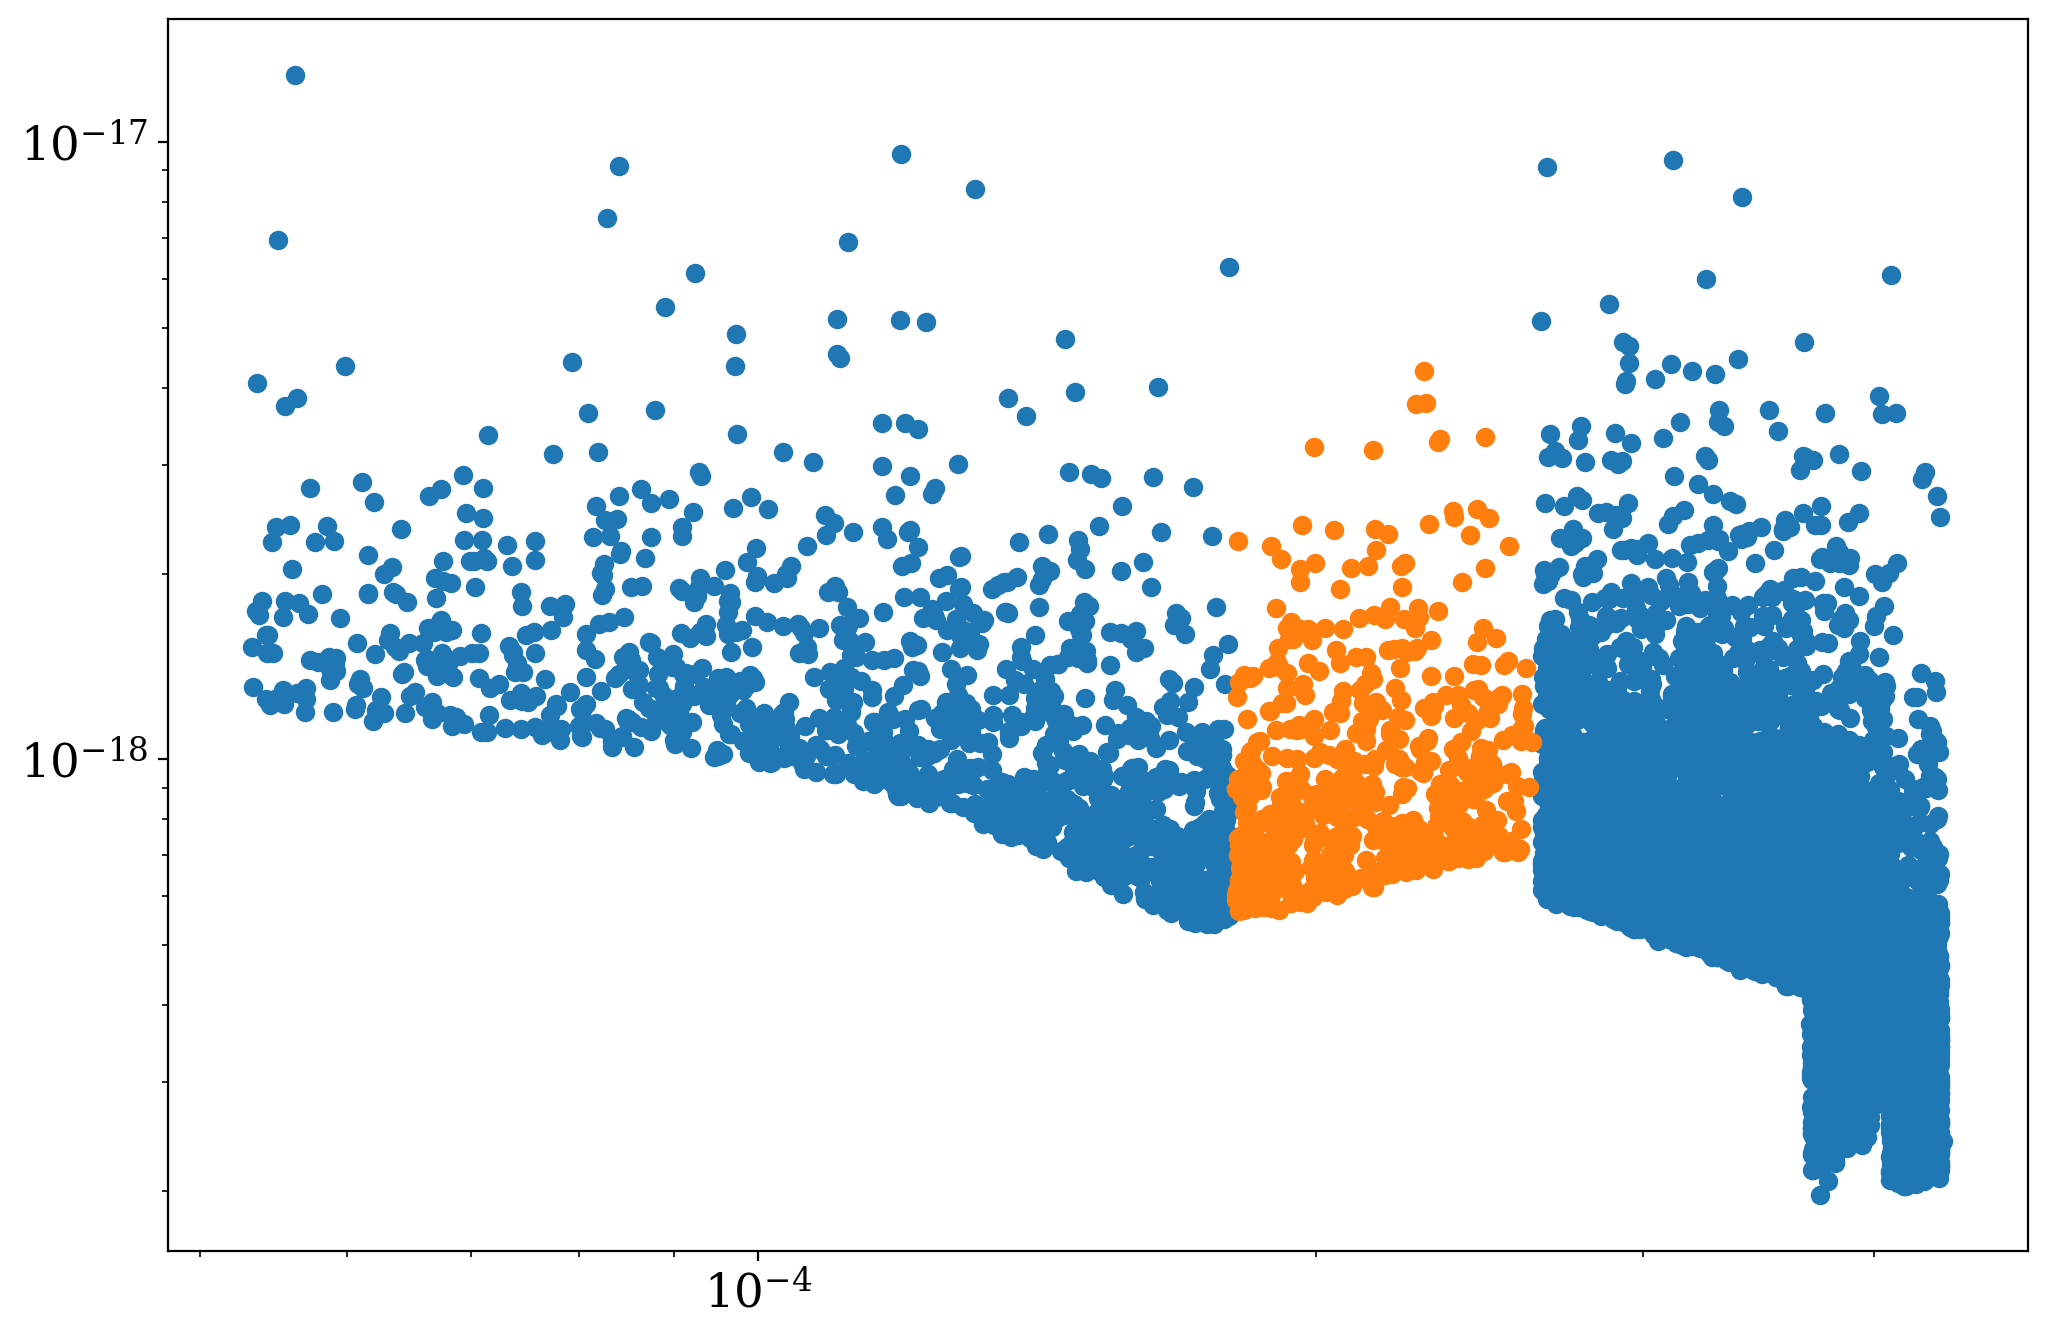

In [40]:
plt.scatter(CV_pop[' f_gw[Hz]'],hs_CVpop.flatten()*np.sqrt(4*3.15e7))
plt.scatter(CV_gap[:, 0],hs_gap.flatten()*np.sqrt(4*3.15e7))
plt.loglog()

In [28]:
np.hstack((fs_CVpop, CV_gap[:, 0]))

array([0.00029971, 0.00031585, 0.00032888, ..., 0.00018255, 0.00022295,
       0.0001922 ], shape=(7821,))

In [32]:
# LSS combine the two populations
allfgws = np.hstack((fs_CVpop, CV_gap[:, 0]))
allhs = np.vstack((hs_CVpop, hs_gap)).flatten()
alllat = np.hstack((lat_CVpop, lat_gap))
alllong = np.hstack((long_CVpop, long_gap))

In [33]:
allfgws.shape, allhs.shape, alllat.shape, alllong.shape

((7821,), (7821,), (7821,), (7821,))

In [34]:
blip_columns = ['f_gw[Hz]','h','lat','long']

blip_df = pd.DataFrame(data=np.vstack((allfgws, allhs, alllat, alllong)).T,columns=blip_columns)

In [35]:
blip_df

,f_gw[Hz],h,lat,long
0,0.000300,5.097921e-23,0.870568,4.218573
1,0.000316,5.988171e-23,1.199207,4.882598
2,0.000329,4.843645e-23,0.240323,2.179752
3,0.000343,5.112263e-23,0.489618,1.874893
4,0.000329,1.701366e-22,-0.713286,4.823727
...,...,...,...,...
7816,0.000255,6.578660e-23,1.003164,6.065362
7817,0.000185,8.805880e-23,-0.205554,1.354776
7818,0.000183,6.558737e-23,-0.155643,4.096195
7819,0.000223,6.320839e-23,-0.334466,4.575816


In [46]:
datapath = '/home/levis/lisa_projects/blip_CVs/datasets/gapfilled/'
blip_df.to_csv(datapath+'dat_mD1000_final_emgapfilled_blip_20260223.txt',index=False,sep=' ',header=False)

[]

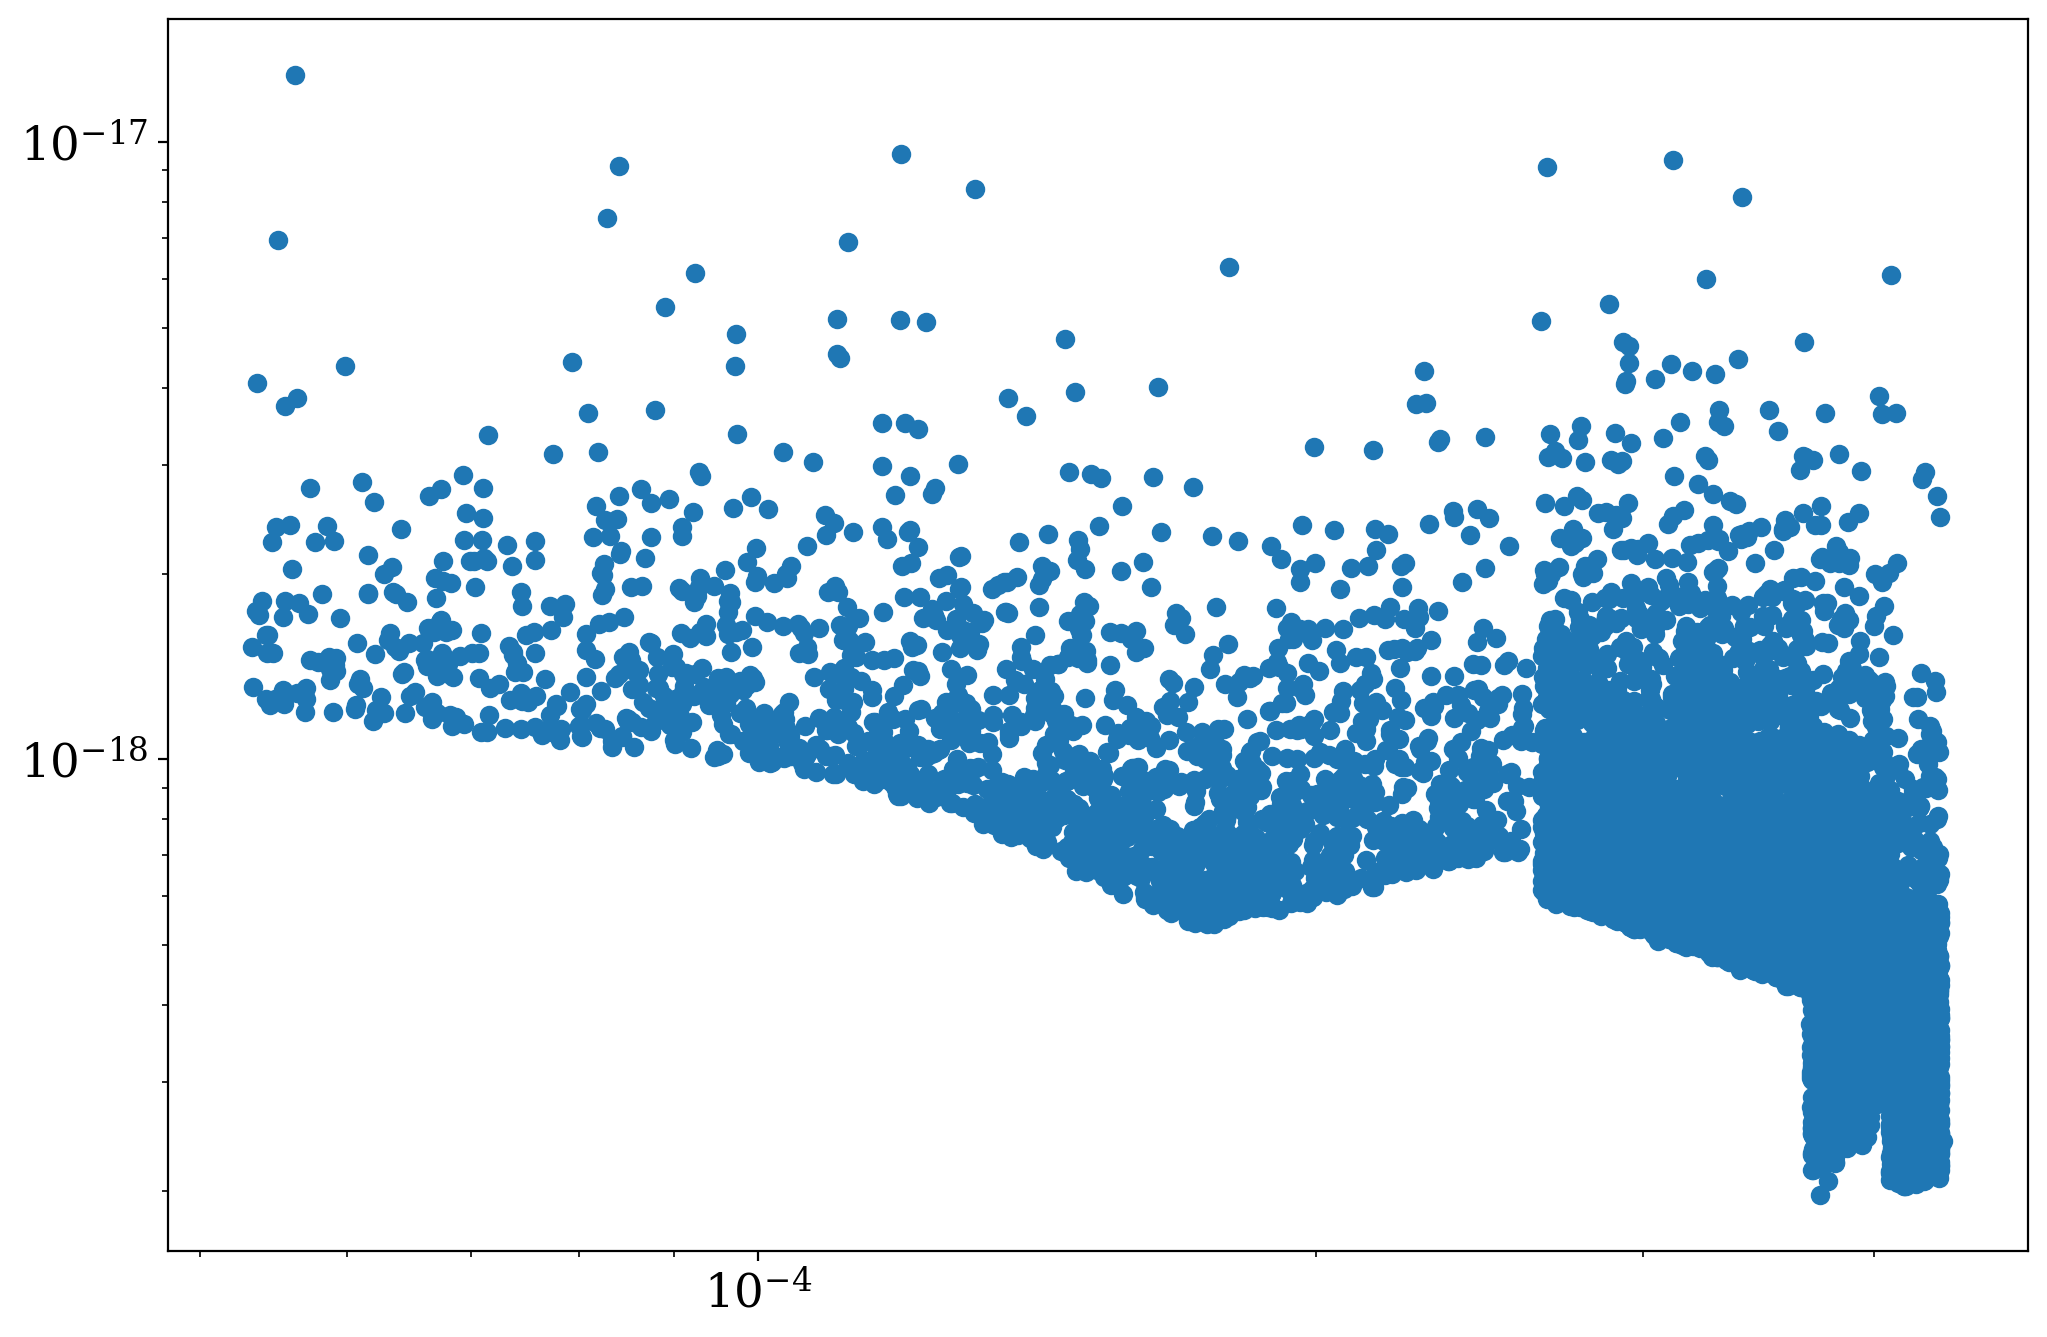

In [37]:
plt.scatter(blip_df['f_gw[Hz]'],blip_df['h']*np.sqrt(4*3.15e7))
plt.loglog()

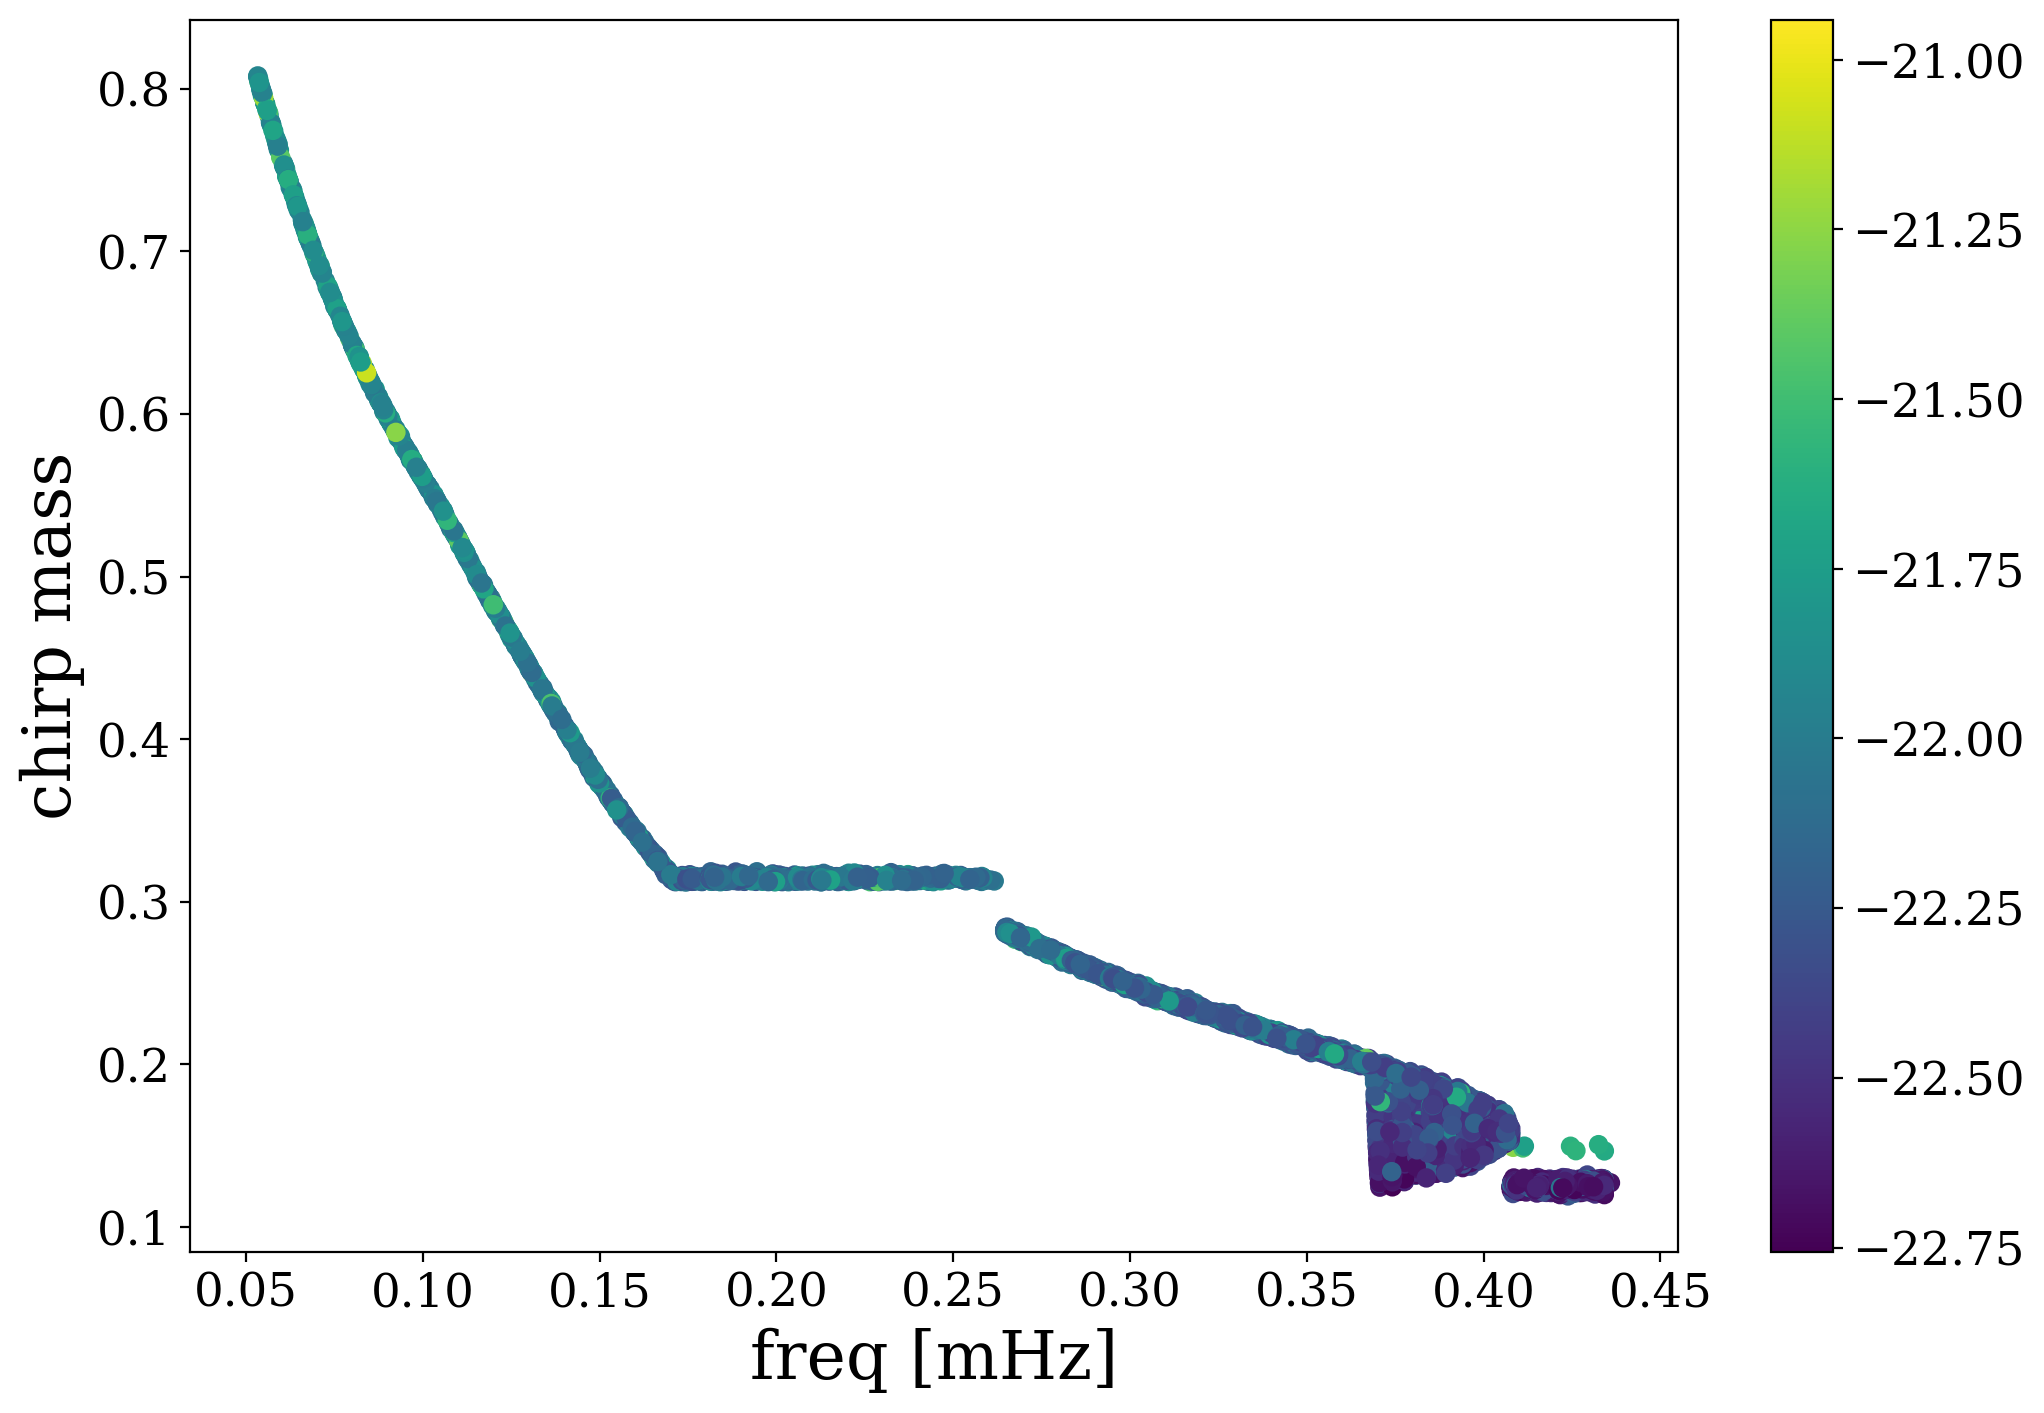

In [44]:
plt.scatter(blip_df['f_gw[Hz]']*1e3, np.hstack((mc_CVpop.value, mc_gap.value)).flatten(), c=np.log10(blip_df['h']))
plt.xlabel('freq [mHz]')
plt.ylabel('chirp mass')
plt.colorbar()